Simulated images: make fake voxels; test in (a) simulations/lme.ipynb (ground-truth); (b) full pipeline (used for actual data) (to test the pipeline)

So we can simulate *n* voxels, save as a Nifti image.

We do this for each week.

Then, for each voxel:
- load it and run it through simulations
- run the full image through the pipeline - we can return the betas/B image and/or see the values in the final image.

The betas from the latter should be the same as the betas from the simulations.



We can try this on just one voxel at first. So have 1 voxel across *k* = 5 weeks.


We have one voxel for some number of *s* subjects.


So if we have just one voxel in the image, we have the regression running on that one voxel. Then, for the beta images for each week, we can find that voxel with max (or from its location - same location in beta as where we inserted it here). (The other voxels should be zero!)

In [215]:
import numpy as np
import nibabel as nib
from nilearn import plotting as npl
from pathlib import Path
import smarts_cerebellum.globals as gl

# template
template_img = '/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/tpl-MNI152NLin2009cSymC_T1w.nii'
template_img = nib.load(template_img)

In [216]:
N_p = 10 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

np.random.seed(13) # make sure we get the same random numbers each time
voxels = np.random.rand(N_t,N_p) # 5 weeks, 10 subjects

In [217]:
# v_i for i^th week; one value for each subject

v0 = voxels[0,:] # W0
v1 = voxels[1,:] # W4
v2 = voxels[2,:] # W12
v3 = voxels[3,:] # W24
v4 = voxels[4,:] # W52

In [199]:
v0

array([0.77770241, 0.23754122, 0.82427853, 0.9657492 , 0.97260111,
       0.45344925, 0.60904246, 0.77552651, 0.64161334, 0.72201823])

In [245]:
def subj_images():
    all_matrices =[]
    for week in range(N_t): # week number
        # each week gets its own voxels
        w_voxels = voxels[week,:]
        for s in range(N_p): # subj number
            # each subject gets their own voxel (singular!) from the week_voxels array

            # empty matrix for each subj-week
            sw_matrix = np.zeros(template_img.shape)
            sw_matrix[1,:,:] = w_voxels[s]
            all_matrices.append(sw_matrix)
    return all_matrices


In [246]:
all_matrices = subj_images()
# order of matrices in all_matrices: week-subj; so the first 10 entries are each of the 10 subjects at w0

In [247]:
np.count_nonzero(all_matrices[1])

7900

In [ ]:
# save the matrices
# the first 10 matrices are for week 0
week0_matrices = all_matrices[:10]
for subj in range(N_p):
    arr = week0_matrices[subj]
    img = nib.Nifti1Image(arr, template_img.affine)
    nib.save(img, f'{gl.baseDir}/simulations/simulated_subj{subj}_W{0}.nii.gz')
# all our images will just be one bar - a bunch of voxels

In [214]:
for t in range(N_t):
    week_matrices = all_matrices[10*t : 10*t + 10] # access 10 elts
    for subj in range(N_p):
        arr = week_matrices[subj] # get that subject's matrix from list of week matrices
        img = nib.Nifti1Image(arr, template_img.affine)
        subj_dir = Path(gl.baseDir)/'simulations'/f'subj{subj}'
        subj_dir.mkdir(parents = True, exist_ok = True)
        nib.save(img, f'{gl.baseDir}/simulations/subj{subj}/simulated_subj{subj}_W{t}.nii.gz')

In [ ]:
# make df that has all the weeks available for each subj
import pandas as pd
df = pd.DataFrame({'subj': np.repeat(range(N_p), N_t), 'week': np.tile(range(N_t), N_p)})

In [288]:
df

,subj,week
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4
5,1,0
6,1,1
7,1,2
8,1,3
9,1,4


In [146]:
v0_matrix = np.zeros(template_img.shape)

# we need 10 images per week
v0_matrix[1,::] = v0[1]

In [126]:
v0_matrix

array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        ...,
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        [0.2

In [106]:
v0_matrix.max()

np.float64(0.2375412200349123)

In [107]:
v0_matrix[1:]

array([[[0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        ...,
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122],
        [0.23754122, 0.23754122, 0.23754122, ..., 0.23754122,
         0.23754122, 0.23754122]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0. 

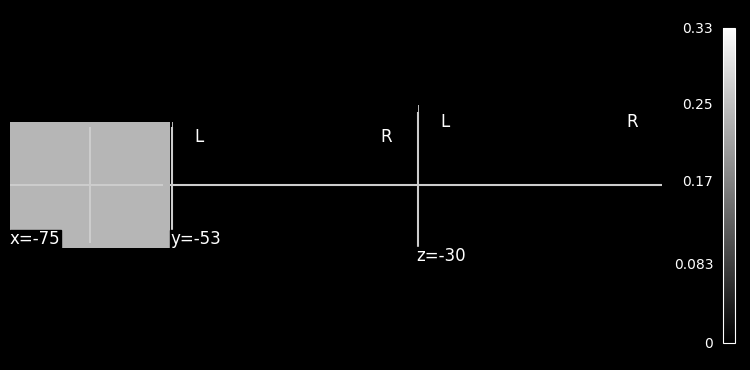

In [108]:
v0_img = nib.Nifti1Image(v0_matrix, template_img.affine)
npl.plot_anat(v0_img)